In [1]:
from everest import Reader, Writer, load

from planetengine.systems import *
from planetengine.initials import *
from planetengine.functions import *
from planetengine.visualisation import quickShow
from planetengine import set_global_anchor

In [19]:
system = Isovisc(
    res=32, alpha=1e4, f=0.1,
    temperatureField=PostSinusoidal(
        factor=1.1,
        prior=Conductive(),
        ),
    observers=True,
    )

:
:
;
:
;



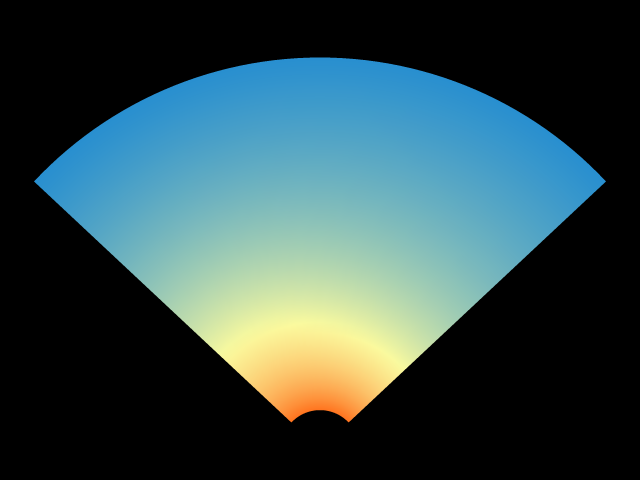


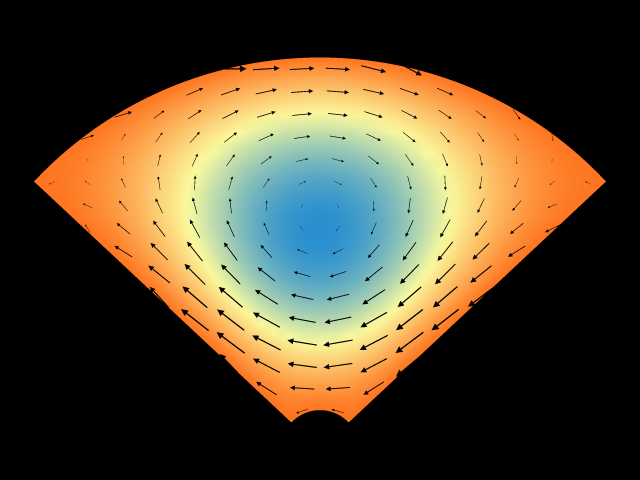

In [20]:
system.show()

In [2]:
set_global_anchor('test', '.')

system = Isovisc(res=32, alpha=1e4)
system[:0.01]()

:
>
:
..


In [7]:
system.chron

0.0101237809241

In [8]:
system.initialise()

In [13]:
system.save()

:


In [12]:
system[:0.01]()

>
:
..



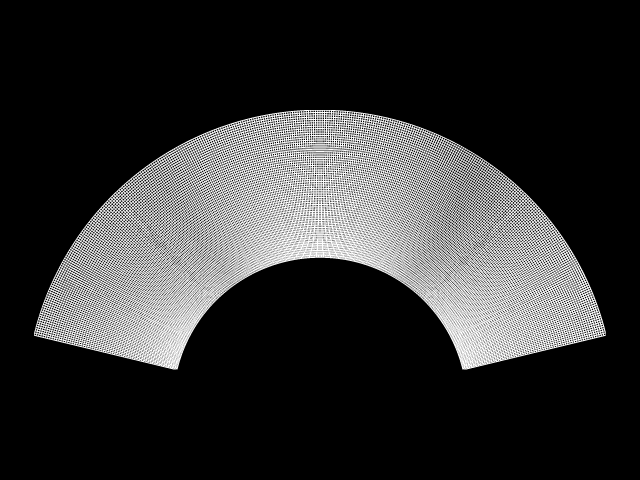

In [16]:
quickShow(system.locals.mesh)

:
:
;
:
;



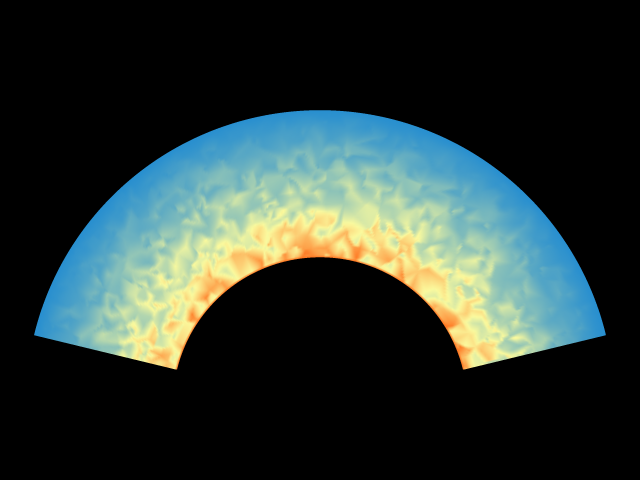


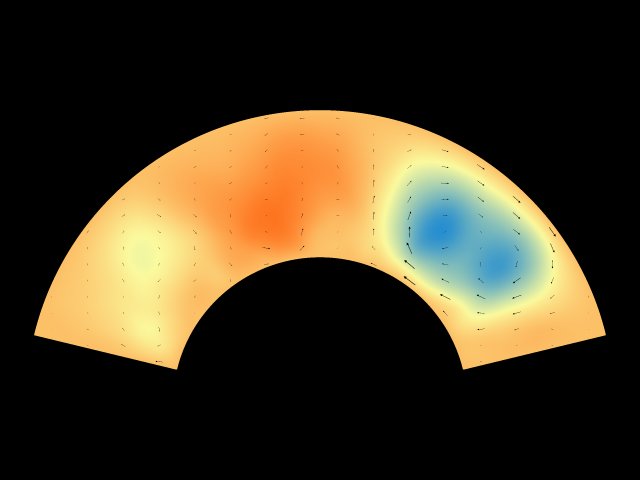

Nu          :  0.70903
Nu_freq     : 15
Nu_min      :  0.49920
Nu_range    :  0.49873
chron       :  0.00000
count       :  0
temp_av     :  0.27497
temp_min    :  0.00000
temp_range  :  1.00000
theta_av    : -0.11306
theta_min   : -0.51902
theta_range :  0.54439
VRMS                   :    2432.251548019185
chron                  :       0.00000
count                  :       0
psi_av                 :    -254.49562
psi_min                :   -1823.62440
psi_range              :    2536.68589
strainRate_outer_av    :    7678.20854
strainRate_outer_min   :     137.63193
strainRate_outer_range :   84094.93858
stressAng_outer_av     : -811827.31376
stressAng_outer_min    : -827028.25988
stressAng_outer_range  :   50224.54433
stressRad_outer_av     : -828457.42180
stressRad_outer_min    : -866183.49692
stressRad_outer_range  :   99650.83767
velAng_outer_av        :    1299.97169
velAng_outer_min       :   -2035.69653
velAng_outer_range     :    7692.79471
velMag_range           :    7239.

In [15]:
system = Isovisc(
    temperatureField=Noisy(factor=1.5, prior=Conductive()),
#     temperatureField=Conductive(),
    aspect=4.,
    f=0.5,
    observers=True,
    )
system.show()
system.report()

In [19]:
import numpy as np
from numpy.random import default_rng
from scipy.interpolate import LinearNDInterpolator

from planetengine import meshutils, mapping

factor = 1.5
freq = 100.
seed = 0

mesh = system.locals.mesh
test = mesh.add_variable(1)
test.data[:] = prior_data = system.locals.temperatureField.data

coordArray = mapping.box(mesh, mesh.data)

meshUtils = meshutils.get_meshUtils(mesh)
(xmin, xmax), (ymin, ymax) = meshUtils.scales
xrange, yrange = xmax - xmin, ymax - ymin
npoints = int(round(freq**2 * xrange / yrange))

rng = default_rng(seed)
randcoords = np.stack(
    (
        rng.standard_normal(npoints) * xrange + xmin,
        rng.standard_normal(npoints) * yrange + ymin,
        ),
    axis=1,
    )
randdata = rng.uniform(size=len(randcoords)) * 2 - 1

unboxed = mapping.unbox(mesh, coordArray)

pertArray = np.nan_to_num(
    LinearNDInterpolator(randcoords, randdata)(*unboxed.transpose())
    ).reshape(len(coordArray), 1)

# randbox = mapping.box(mesh, randcoords)
# randbox = randbox[
#     (randbox[:, 0] > 0) & (randbox[:, 0] < 1)
#     & (randbox[:, 1] > 0) & (randbox[:, 1] < 1)
#     ]






out = factor ** pertArray * prior_data

In [17]:
randcoords.shape

(22030, 2)

In [18]:
randdata.shape

(22030,)

In [ ]:
randcoords.shape

In [ ]:
mapping.unbox(mesh, coordArray)


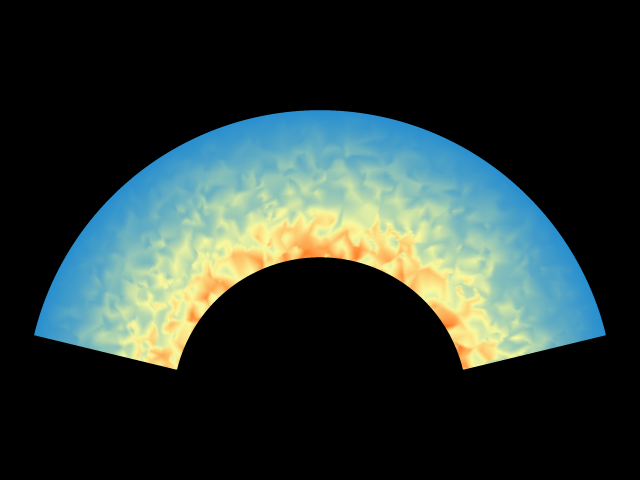

In [20]:
test.data[:] = out
quickShow(test)

In [14]:
mapping.unbox(mesh, coordArray)

array([[ 0.9719379 ,  0.23523757],
       [ 0.98712443,  0.23891316],
       [ 1.00231096,  0.24258875],
       ..., 
       [-1.91350274,  0.46312397],
       [-1.92868927,  0.46679956],
       [-1.9438758 ,  0.47047515]])